In [8]:
from copy import deepcopy
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.isothermal_flow import (
    NSIsothermalIntraTrajectoryGLSConfig,
    add_heteroscedastic_noise_temporal_derivative,
    build_ns_isothermal_intra_trajectory_artifacts,
    build_ns_isothermal_weak_validation_blocks,
    generate_isothermal_ns_dataset,
    get_ns_isothermal_feature_names,
    run_ns_isothermal_intra_trajectory_gls_experiment,
)
from mfsindy.experiments import (
    evaluate_weak_form_models,
    fit_intra_trajectory_gls_models,
    format_coefficient_equations,
    make_metric_scorer,
    optimize_hyperparams,
    split_spatiotemporal_trajectory,
)
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white", font_scale=1.1)

cfg = NSIsothermalIntraTrajectoryGLSConfig(
    n_runs=25,
    N=32,
    Nt=1000,
    L=5.0,
    T=10.0,
    mu=1.0,
    K=1000,
    RT=1.0,
    sigma0=1e-12,
    alpha=0.1,
    stlsq_threshold=0.5,
    stlsq_alpha=1e-12,
    n_ensemble_models=100,
    seed_base=1,
    results_dir="results",
    results_filename="ns_isothermal_weighted_errors.csv",
)


# Navier-Stokes Part 2 — Intra-trajectory GLS

This notebook compares three different strategies for properly fit a SINDy model on a trajectory characterized by heteroskedastik noise: 
- *No weighting* (`WeakPDELibrary`)
- *Variance GLS* (`WeightedWeakPDELibrary`, weights = variance_scaled)
- *Unitary GLS* (`WeightedWeakPDELibrary`, weights = 1, only correlation effect)

## Governing equations

We consider the two-dimensional isothermal compressible Navier--Stokes system on a periodic domain. Let $u(x,y,t)$ and $v(x,y,t)$ denote the two velocity components, and let \(\rho(x,y,t)\) denote the density. The governing equations are

$$
\begin{aligned}
u_t &= -\bigl(u u_x + v u_y\bigr) - \frac{1}{\rho}\Bigl(p_x - \mu (u_{xx}+u_{yy})\Bigr), \\
v_t &= -\bigl(u v_x + v v_y\bigr) - \frac{1}{\rho}\Bigl(p_y - \mu (v_{xx}+v_{yy})\Bigr), \\
\rho_t &= -\left(\frac{u\,p_x}{RT} + \frac{v\,p_y}{RT} + \rho u_x + \rho v_y\right),
\end{aligned}
$$

where the pressure is given by the isothermal equation of state

$$
p = \rho RT.
$$

In all simulations, we set
$$
\mu = 1, \qquad RT = 1.
$$

Let $U = (u,v,\rho)^\top$ denote the system state. To model perturbation error, we add a zero-mean random noise term $\epsilon$ to the state, defining

$$
U^{\mathrm{noisy}} = U + \epsilon.
$$

The perturbation is assumed to satisfy
$$
\mathbb{E}[\epsilon] = 0.
$$

The pointwise noise variance is modeled as

$$
\operatorname{Var}(\epsilon) = \left(\sigma_0 + \alpha \sqrt{u_t^2 + v_t^2}\right)^2,
$$

where $\sigma_0 > 0$ is a baseline noise level and $\alpha = 0.25$ controls the strength of the heteroscedastic component.

## Trajectories

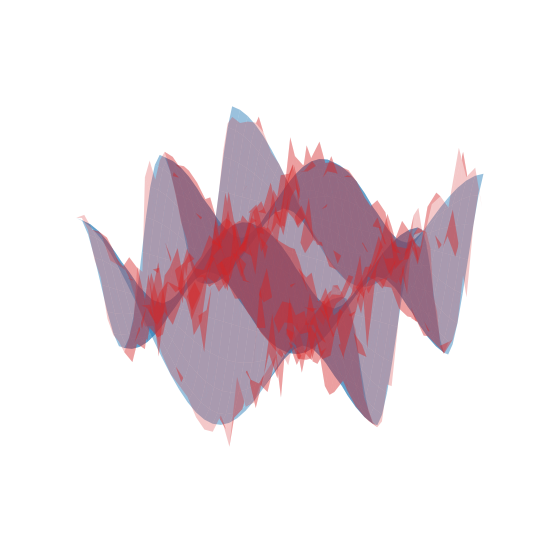

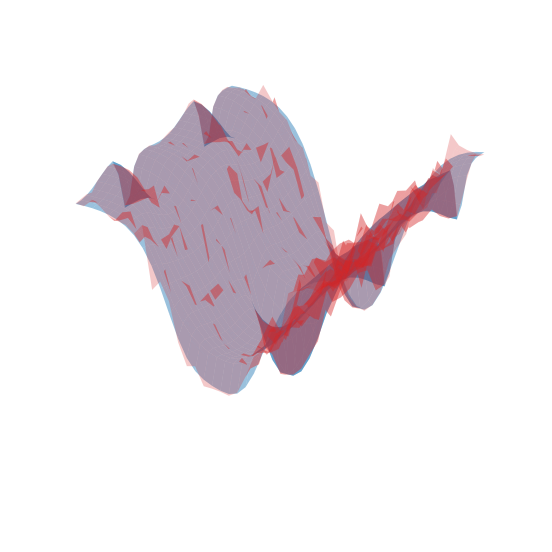

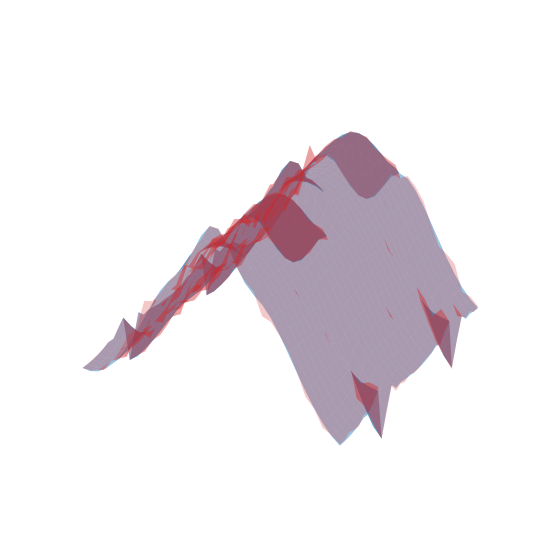

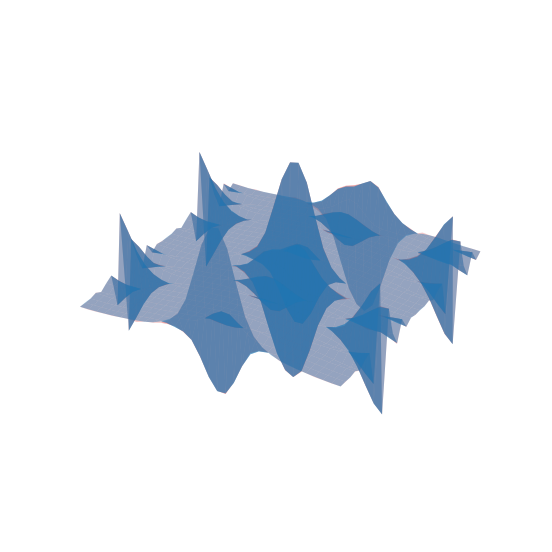

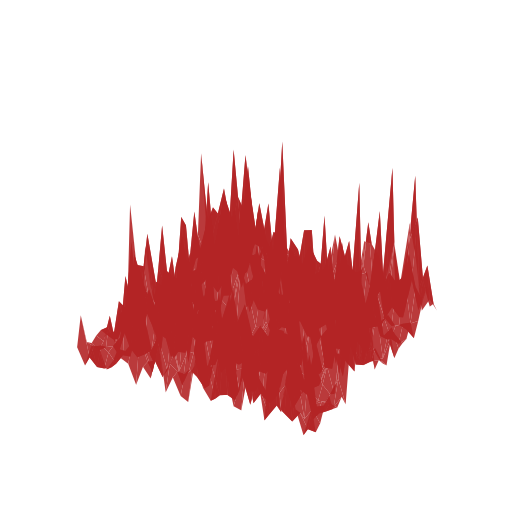

In [9]:
from mfsindy.cases.isothermal_flow import generate_isothermal_ns_dataset
from mfsindy.cases.isothermal_flow_plots import plot_trajectories_additive_noise, plot_residuals

U_true, t_eval, grid = generate_isothermal_ns_dataset(
    N=cfg.N,
    Nt=cfg.Nt,
    L=cfg.L,
    T=cfg.T,
    mu=cfg.mu,
    RT=cfg.RT,
    seed=0,
    ic_type="taylor-green",
)
U_noisy = plot_trajectories_additive_noise(
    grid=grid,
    u_true=U_true,
    alpha=cfg.alpha,
    sigma0=cfg.sigma0,
    time_indices=[0],
    component=2)
U_noisy = plot_trajectories_additive_noise(
    grid=grid,
    u_true=U_true,
    alpha=cfg.alpha,
    sigma0=cfg.sigma0,
    time_indices=[249],
    component=2)
U_noisy = plot_trajectories_additive_noise(
    grid=grid,
    u_true=U_true,
    alpha=cfg.alpha,
    sigma0=cfg.sigma0,
    time_indices=[499],
    component=2)
U_noisy = plot_trajectories_additive_noise(
    grid=grid,
    u_true=U_true,
    alpha=cfg.alpha,
    sigma0=cfg.sigma0,
    time_indices=[999],
    component=2)
plot_residuals(grid, U_true, U_noisy)


## Hyperparameter Selection

Use one noisy isothermal-flow trajectory realisation, split it 80-20 in time, tune the weak-form hyperparameters separately for each weighting strategy by maximizing held-out weak-form $R^2$, then refit each model on the full trajectory and print the resulting equations.


In [10]:

# RAW_H_XY_CANDIDATES = [cfg.L / 5.0]
# RAW_H_T_CANDIDATES = [cfg.T / 50.0]

# U_clean_search, t_search, grid_search = generate_isothermal_ns_dataset(
#     N=cfg.N,
#     Nt=cfg.Nt,
#     L=cfg.L,
#     T=cfg.T,
#     mu=cfg.mu,
#     RT=cfg.RT,
#     seed=cfg.seed_base,
#     ic_type="taylor-green",
# )
# rng_search = np.random.default_rng(cfg.seed_base + 123)
# U_noisy_search, variance_search = add_heteroscedastic_noise_temporal_derivative(
#     U_clean_search,
#     t_search,
#     sigma0=cfg.sigma0,
#     alpha=cfg.alpha,
#     rng=rng_search,
# )

# U_train, U_val, t_train, t_val = split_spatiotemporal_trajectory(
#     U_noisy_search,
#     t_search,
#     time_axis=2,
#     validation_fraction=0.2,
#     overlap=0,
# )
# variance_train, _, _, _ = split_spatiotemporal_trajectory(
#     variance_search,
#     t_search,
#     time_axis=2,
#     validation_fraction=0.2,
#     overlap=0,
# )
# grid_train, grid_val, _, _ = split_spatiotemporal_trajectory(
#     grid_search,
#     t_search,
#     time_axis=2,
#     validation_fraction=0.2,
#     overlap=0,
# )
# T_train = float(t_train[-1] - t_train[0])
# T_val = float(t_val[-1] - t_val[0])
# max_h_xy = 0.49 * float(cfg.L)
# max_h_t = 0.49 * min(T_train, T_val)
# H_XY_CANDIDATES = sorted({min(float(h_xy), max_h_xy) for h_xy in RAW_H_XY_CANDIDATES if float(h_xy) > 0.0})
# H_T_CANDIDATES = sorted({min(float(h_t), max_h_t) for h_t in RAW_H_T_CANDIDATES if float(h_t) > 0.0})
# if not H_XY_CANDIDATES or not H_T_CANDIDATES:
#     raise ValueError("No feasible H_xt candidates remain after enforcing the train/validation window sizes.")

# SEARCH_GRID = {
#     "stlsq_threshold": [0.25],
#     "H_xt": [[h_xy, h_xy, h_t] for h_xy in H_XY_CANDIDATES for h_t in H_T_CANDIDATES],
# }

# methods = ["No weighting", "Variance GLS", "Ones GLS"]
# search_results = {}
# best_params_by_model = {}
# tuned_cfg_by_model = {}
# tuned_equations = {}

# def evaluate_candidate(candidate_cfg):
#     fit_cfg = deepcopy(candidate_cfg)
#     fit_cfg.Nt = int(t_train.shape[0])
#     fit_cfg.T = T_train
#     validation_cfg = deepcopy(candidate_cfg)
#     validation_cfg.Nt = int(t_val.shape[0])
#     validation_cfg.T = T_val
#     artifacts = build_ns_isothermal_intra_trajectory_artifacts(
#         U_train,
#         t_train,
#         grid_train,
#         variance=variance_train,
#         cfg=fit_cfg,
#         weak_seed=fit_cfg.seed_base + 40_000,
#     )
#     coef_map = fit_intra_trajectory_gls_models(fit_cfg, artifacts, methods)
#     validation_blocks = build_ns_isothermal_weak_validation_blocks(
#         validation_cfg,
#         [U_val],
#         grid=grid_val,
#         weak_seed=validation_cfg.seed_base + 40_010,
#         group_name="validation",
#     )
#     return evaluate_weak_form_models(coef_map, validation_blocks)

# for target_model in methods:
#     search = optimize_hyperparams(
#         cfg,
#         param_grid=SEARCH_GRID,
#         evaluate=evaluate_candidate,
#         score_fn=make_metric_scorer(source=target_model, metric="weak_r2", source_col="model"),
#         maximize=True,
#     )
#     tuned_cfg = deepcopy(search.best_config)
#     search_results[target_model] = search
#     best_params_by_model[target_model] = search.best_params
#     tuned_cfg_by_model[target_model] = tuned_cfg
#     full_artifacts = build_ns_isothermal_intra_trajectory_artifacts(
#         U_noisy_search,
#         t_search,
#         grid_search,
#         variance=variance_search,
#         cfg=tuned_cfg,
#         weak_seed=tuned_cfg.seed_base + 40_001,
#     )
#     full_coef_map = fit_intra_trajectory_gls_models(tuned_cfg, full_artifacts, methods)
#     tuned_equations[target_model] = full_coef_map[target_model]

# feature_names = get_ns_isothermal_feature_names(
#     cfg,
#     grid=grid_search,
#     reference_trajectory=U_noisy_search,
# )
# print(pd.DataFrame(best_params_by_model).T)
# print(
#     format_coefficient_equations(
#         tuned_equations,
#         feature_names=feature_names,
#         state_names=("u_t", "v_t", "rho_t"),
#         precision=3,
#     )
# )


## Run


In [11]:
# methods = ["No weighting", "Variance GLS", "Ones GLS"]
# df_errors_parts = []
# for method_name in methods:
#     method_cfg = deepcopy(tuned_cfg_by_model[method_name])
#     method_cfg.results_filename = f"navierstokes_part2_{method_name.lower().replace(' ', '_')}.csv"
#     df_method, _, _ = run_ns_isothermal_intra_trajectory_gls_experiment(method_cfg)
#     df_errors_parts.append(df_method[df_method["method"] == method_name].copy())

# df_errors = pd.concat(df_errors_parts, ignore_index=True)
# errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
# df_errors.to_csv(errors_path, index=False)


## Errors

In [12]:
methods = ["No weighting", "Variance GLS", "Ones GLS"]


errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)

L1_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L1")
    ]["value"].to_numpy()
    for m in methods
}
L0_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L0")
    ]["value"].to_numpy()
    for m in methods
}

print("\nMedian L1 errors (reloaded from CSV):")
for m in methods:
    print(f"{m:14s} : {np.median(L1_errors[m]):.3e}")

print("\nMedian L0 support errors (reloaded from CSV):")
for m in methods:
    print(f"{m:14s} : {np.median(L0_errors[m]):.3e}")



Median L1 errors (reloaded from CSV):
No weighting   : 4.234e-02
Variance GLS   : 6.526e-03
Ones GLS       : 6.780e-03

Median L0 support errors (reloaded from CSV):
No weighting   : 1.000e+00
Variance GLS   : 1.429e-01
Ones GLS       : 1.429e-01


### L1 Error

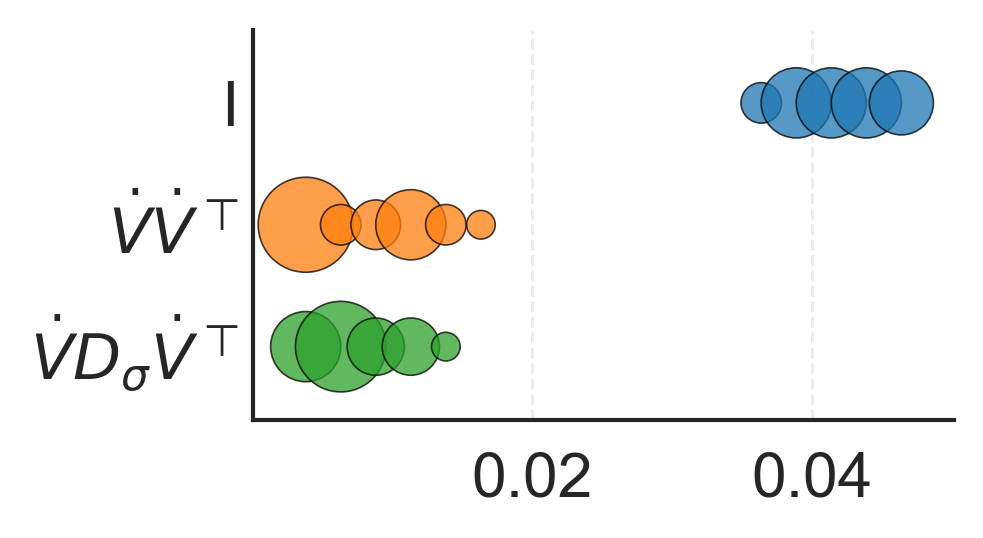

In [13]:
method_colors = {
    "No weighting": "tab:blue",
    "Variance GLS": "tab:green",
    "Ones GLS": "tab:orange",
}
methods = ["Variance GLS", "Ones GLS", "No weighting"]
labels = [r"$\dot{V}D_\sigma\dot{V}^\top$",r"$\dot{V}\dot{V}^\top$","I"]

all_l1_values = np.concatenate([
    np.asarray(L1_errors[m], dtype=float)
    for m in methods
])

xmin = float(np.min(all_l1_values))-0.001
xmax = float(np.max(all_l1_values))+0.001
pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)

l1_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=L1_errors,
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels,
    xlim=l1_xlim,
    save_path="results/l1_2",
)


### L0 Error

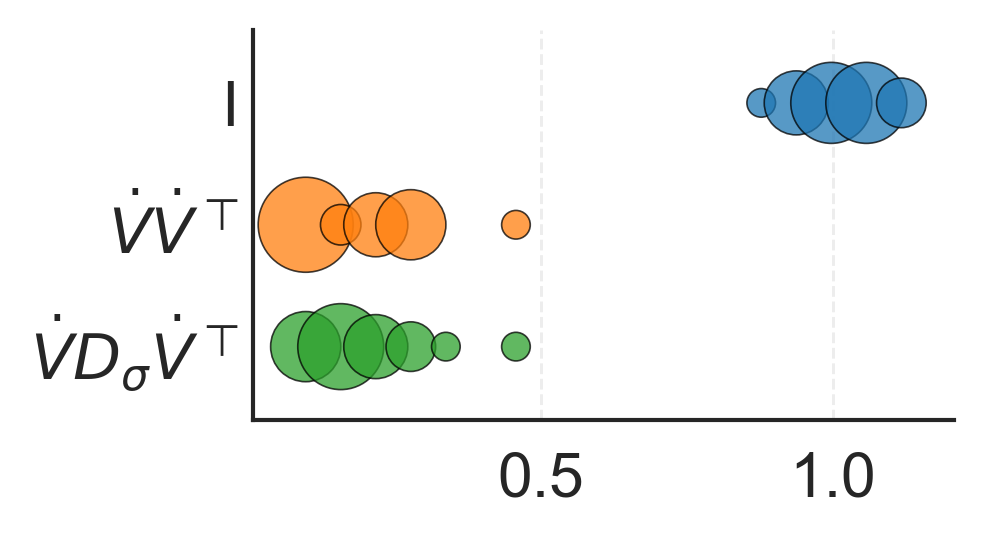

In [14]:
all_l0_values = np.concatenate([
    np.asarray(L0_errors[m], dtype=float)
    for m in methods
])

xmin = float(np.min(all_l0_values))-0.01
xmax = float(np.max(all_l0_values))+0.01

pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)
l0_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=L0_errors,
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels,
    xlim=l0_xlim,
    save_path="results/l0_2"
)
